# Поиск статей справки по вопросу пользователя

Задача: по тексту обращения вернуть ранжированный список `article_id` для передачи в RAG-пайплайн. Метрика `MAP@10`.

Схема: гибридный поиск из нескольких сигналов (BM25 по леммам, TF-IDF по символьным и словесным n-граммам, LSA и - если доступна - локальная нейросетевая модель эмбеддингов) со статьями, разбитыми на пассажи, и градиентный бустинг для переранжирования кандидатов.

Приложенный `answer.csv` получен на лексических сигналах. В ноутбуке есть опциональный хук для локальных нейро-эмбеддингов (`USE_EMB`, по умолчанию выключен): модель легальна по правилам (<1B, без внешних API), но в измеренный результат не входит из-за ограничений по времени и ресурсам - это направление на развитие.

Запуск: положить `articles.f`, `calibration.f`, `test.f` рядом с ноутбуком и выполнить все ячейки. На выходе `answer.csv`.


In [1]:
import re
import html as html_lib
from functools import reduce
from collections import Counter

import numpy as np
import pandas as pd
from bs4 import BeautifulSoup
import pymorphy3
from rank_bm25 import BM25Okapi
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize
from sklearn.ensemble import HistGradientBoostingClassifier

try:
    import matplotlib.pyplot as plt
    HAS_PLT = True
except ModuleNotFoundError:
    HAS_PLT = False

DATA_DIR = "."
SEED = 42

USE_EMB = False
EMB_MODEL = "intfloat/multilingual-e5-base"


## Данные


In [2]:
articles = pd.read_feather(f"{DATA_DIR}/articles.f")
calibration = pd.read_feather(f"{DATA_DIR}/calibration.f")
test = pd.read_feather(f"{DATA_DIR}/test.f")

print(articles.shape, calibration.shape, test.shape)
articles.head(3)


(793, 3) (500, 3) (500, 2)


/Users/macbook/Downloads/Тестовое Avito Bootcamp DS/#/lib/python3.11/site-packages/pandas/io/feather_format.py:178: FutureWarning: pyarrow.feather.read_table is deprecated as of 24.0.0. Use pyarrow.ipc.open_file() / RecordBatchFileReader instead. Feather V2 is the Arrow IPC file format.
  pa_table = feather.read_table(


,article_id,title,body
0,1730,Имя или название компании,"<ol><li><p>Зайдите в раздел <a href=""https://w..."
1,1746,"Понять, что профиль заблокирован","<p>Проверьте, какое сообщение вы видите при вх..."
2,1747,Не допустить блокировки профиля,<ol><li><p><strong>Не заводите несколько аккау...


In [3]:
gt_sizes = calibration["ground_truth"].str.split().apply(len)
print(gt_sizes.value_counts().sort_index())
print("\nдлина body, символов:")
print(articles["body"].str.len().describe()[["mean", "50%", "max"]])


ground_truth
1    279
2    182
3     38
4      1
Name: count, dtype: int64

длина body, символов:
mean    8538.161412
50%          3513.0
max        901357.0
Name: body, dtype: Float64


У большинства запросов 1-2 правильные статьи, встречаются 3-4. Статьи сильно различаются по длине: медиана около 3 тысяч символов, максимум сотни тысяч. Это важно для выбора схемы индексации (см. раздел про чанки).


## Обработка текста

HTML статей содержит таблицы, вкладки и спойлеры. Весь текст присутствует в разметке статически, поэтому `get_text()` достаёт и содержимое вкладок.

Русский язык флективный, поэтому нужна лемматизация: формы 'отправить', 'отправляю', 'отправка' должны совпадать. Использую `pymorphy3` (форк `pymorphy2` под актуальный Python), словари идут в пакете, обращений в сеть нет.

Плейсхолдеры анонимизации (`<DATE>`, `<MONEY>`, `<PHONE>`, `<ID>`, `<URL>`) встречаются примерно в 9% запросов. Если их не вырезать, они лемматизируются как английские слова и зашумляют лексические сигналы.


In [4]:
morph = pymorphy3.MorphAnalyzer()
lemma_cache = {}

TOKEN_RE = re.compile(r"[а-яёa-z0-9]+", re.IGNORECASE)
PLACEHOLDER_RE = re.compile(r"<(DATE|MONEY|PHONE|ID|URL)>", re.IGNORECASE)

STOPWORDS = {
    "и", "в", "во", "не", "что", "он", "на", "я", "с", "со", "как", "а", "то", "все",
    "она", "так", "его", "но", "да", "ты", "к", "у", "же", "вы", "за", "бы", "по",
    "только", "ее", "мне", "было", "вот", "от", "меня", "еще", "нет", "о", "из",
    "ему", "теперь", "когда", "даже", "ну", "вдруг", "ли", "если", "уже", "или",
    "быть", "был", "него", "до", "вас", "нибудь", "опять", "уж", "вам", "сказал",
    "ведь", "там", "потом", "себя", "ничего", "ей", "может", "они", "тут", "где",
    "есть", "надо", "ней", "для", "мы", "тебя", "их", "чем", "была", "сам", "чтобы",
    "без", "будто", "человек", "чего", "раз", "тоже", "себе", "под", "будет", "ж",
    "тогда", "кто", "этот", "того", "потому", "этого", "какой", "совсем", "ним",
    "здесь", "этом", "один", "почти", "мой", "тем", "нее", "сейчас", "были", "куда",
    "зачем", "всех", "никогда", "можно", "при", "об", "это", "эта", "эти",
    "пожалуйста", "здравствуйте", "добрый", "день", "вечер", "подскажите",
    "скажите", "спасибо",
}


def clean_html(raw):
    if not raw:
        return ""
    text = BeautifulSoup(html_lib.unescape(raw), "lxml").get_text(separator=" ", strip=True)
    return re.sub(r"\s+", " ", text).strip()


def tokenize(text):
    return TOKEN_RE.findall(PLACEHOLDER_RE.sub(" ", text).lower())


def lemmatize(tokens, drop_stop=True):
    out = []
    for tok in tokens:
        if tok.isdigit():
            out.append(tok)
            continue
        lemma = lemma_cache.get(tok)
        if lemma is None:
            lemma = morph.parse(tok)[0].normal_form
            lemma_cache[tok] = lemma
        if drop_stop and lemma in STOPWORDS:
            continue
        out.append(lemma)
    return out


In [5]:
sample = articles.iloc[1]
print(clean_html(sample["body"])[:200])
print()
print(lemmatize(tokenize(clean_html(sample["body"])))[:15])


Проверьте, какое сообщение вы видите при входе в профиль. Профиль заблокирован Доступ к профилю ограничен Доступ ограничен. Пройдите проверку по лицу Фраза под Профиль заблокирован будет отличаться в 

['проверить', 'сообщение', 'видеть', 'вход', 'профиль', 'профиль', 'заблокировать', 'доступ', 'профиль', 'ограничить', 'доступ', 'ограничить', 'пройти', 'проверка', 'лицо']


## Индексация

### Зачем чанки

Нужная статья часто это хаб с общим заголовком ('Покупателю', 'Продавцу'), внутри десяток подтем, а релевантный ответ занимает пару предложений в длинном тексте. В скоре по документу целиком такой фрагмент тонет. Ниже это подтверждается замером (раздел 'Документный baseline').

Режу статьи длиннее 150 слов на пересекающиеся окна по 150 слов с шагом 100. Заголовок приписывается каждому чанку с тройным весом. При поиске беру максимум скора по чанкам статьи.

### Сигналы поиска

- **BM25 по леммам** - точный лексический матчинг с учётом морфологии.
- **TF-IDF по символьным n-граммам (3-5)** - устойчив к опечаткам: 'Москлвской' пересекается с 'московский' по большинству триграмм.
- **TF-IDF по словесным n-граммам (1-2) по леммам** - ловит устойчивые словосочетания ('пункт выдачи', 'статус заказа').
- **LSA (TruncatedSVD, 200 компонент)** - линейно-семантический сигнал: сближает термины, часто встречающиеся в одних статьях.
- **Нейро-эмбеддинги** (если доступны) - плотная семантика от локальной модели multilingual-e5, закрывает случаи, где смысл совпадает, а слова разные ('не работает за наличку' против 'Оплата заказов').

Дополнительно строю BM25 отдельно по заголовкам и по телам: реранкеру полезно видеть эти сигналы раздельно.


In [6]:
CHUNK_SIZE, CHUNK_STRIDE = 150, 100


def chunk_words(words, size=CHUNK_SIZE, stride=CHUNK_STRIDE):
    if len(words) <= size:
        return [words]
    chunks, i = [], 0
    while i < len(words):
        chunks.append(words[i:i + size])
        if i + size >= len(words):
            break
        i += stride
    return chunks


titles = articles["title"].apply(clean_html)
bodies = articles["body"].apply(clean_html)

title_lemmas = [lemmatize(tokenize(t)) for t in titles]
body_lemmas = [lemmatize(tokenize(b)) for b in bodies]

chunk_docs, chunk_texts, chunk_lemmas, chunk_owner = [], [], [], []
for idx, (t_lem, body) in enumerate(zip(title_lemmas, bodies)):
    for words in chunk_words(tokenize(body)):
        piece = t_lem * 3 + lemmatize(words)
        chunk_docs.append(piece)
        chunk_texts.append(titles[idx] + " " + titles[idx] + " " + " ".join(words))
        chunk_lemmas.append(" ".join(piece))
        chunk_owner.append(idx)

chunk_owner = np.array(chunk_owner)

bm25_chunks = BM25Okapi(chunk_docs)
char_vec = TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=2, max_features=200_000)
char_matrix = char_vec.fit_transform(chunk_texts)
word_vec = TfidfVectorizer(analyzer="word", ngram_range=(1, 2), min_df=2, sublinear_tf=True)
word_matrix = word_vec.fit_transform(chunk_lemmas)

print(f"статей {len(articles)}, чанков {len(chunk_docs)}")


статей 793, чанков 5734


In [7]:
bm25_title = BM25Okapi(title_lemmas)
bm25_body = BM25Okapi(body_lemmas)

doc_lemmas = [" ".join(t * 2 + b) for t, b in zip(title_lemmas, body_lemmas)]
lsa_vec = TfidfVectorizer(analyzer="word", ngram_range=(1, 1), min_df=2, sublinear_tf=True)
lsa_doc_matrix = lsa_vec.fit_transform(doc_lemmas)
svd = TruncatedSVD(n_components=200, random_state=SEED)
doc_embeddings = normalize(svd.fit_transform(lsa_doc_matrix))

N_DOCS = len(articles)
title_sets = [set(t) for t in title_lemmas]
full_sets = [set(t) | set(b) for t, b in zip(title_lemmas, body_lemmas)]
art_len = np.array([len(b) for b in body_lemmas], dtype=float)
article_ids = np.array(articles["article_id"])
print(f"LSA: {svd.n_components} компонент, объяснённая дисперсия {svd.explained_variance_ratio_.sum():.2f}")


LSA: 200 компонент, объяснённая дисперсия 0.67


### Нейро-эмбеддинги (опционально)

По умолчанию выключено (`USE_EMB=False`): приложенный `answer.csv` лексический, эмбеддинги - опциональный эксперимент, легальный по правилам, но в финале не прогонялся из-за времени и ресурсов. Локальная модель multilingual-e5-base (~278M параметров). Статьи кодируются один раз с префиксом `passage:`, запросы - с `query:` (требование e5). Если `sentence-transformers` не установлен, блок мягко отключается.


In [8]:
emb_ok = False
doc_emb_nn = None
emb_model = None
if USE_EMB:
    try:
        import torch
        from sentence_transformers import SentenceTransformer
        torch.manual_seed(SEED)
        emb_model = SentenceTransformer(EMB_MODEL)
        art_texts = [(titles[i] + ". " + bodies[i])[:2000] for i in range(N_DOCS)]
        doc_emb_nn = emb_model.encode(["passage: " + t for t in art_texts],
                                      batch_size=64, normalize_embeddings=True,
                                      show_progress_bar=False)
        emb_ok = True
        print("нейро-эмбеддинги включены:", EMB_MODEL, doc_emb_nn.shape)
    except Exception as e:
        print("нейро-эмбеддинги ОТКЛЮЧЕНЫ:", type(e).__name__,
              "решение работает на лексических сигналах")


def emb_batch(queries):
    if not emb_ok:
        return None
    q = emb_model.encode(["query: " + t for t in queries],
                         batch_size=64, normalize_embeddings=True, show_progress_bar=False)
    return q @ doc_emb_nn.T


## Поиск и метрика


In [9]:
def to_article_scores(chunk_scores):
    out = np.full(N_DOCS, -np.inf)
    np.maximum.at(out, chunk_owner, chunk_scores)
    out[out == -np.inf] = 0.0
    return out


def bm25_batch(queries):
    out = np.zeros((len(queries), N_DOCS))
    for i, q in enumerate(queries):
        out[i] = to_article_scores(np.asarray(bm25_chunks.get_scores(lemmatize(tokenize(q)))))
    return out


def _chunk_cosine_batch(vec, matrix, texts):
    sims = cosine_similarity(vec.transform(texts), matrix)
    out = np.zeros((len(texts), N_DOCS))
    for i in range(len(texts)):
        np.maximum.at(out[i], chunk_owner, sims[i])
    return out


def char_batch(queries):
    return _chunk_cosine_batch(char_vec, char_matrix, [q + " " + q for q in queries])


def word_batch(queries):
    return _chunk_cosine_batch(word_vec, word_matrix, [" ".join(lemmatize(tokenize(q))) for q in queries])


def lsa_batch(queries):
    texts = [" ".join(lemmatize(tokenize(q))) for q in queries]
    q_emb = normalize(svd.transform(lsa_vec.transform(texts)))
    return q_emb @ doc_embeddings.T


In [10]:
def ap_at_k(predicted, relevant, k=10):
    if not relevant:
        return 0.0
    hits, score = 0, 0.0
    for i, p in enumerate(predicted[:k], start=1):
        if p in relevant:
            hits += 1
            score += hits / i
    return score / min(len(relevant), k)


def map_at_k(preds, rels, k=10):
    return float(np.mean([ap_at_k(p, r, k) for p, r in zip(preds, rels)]))


def norm_rows(M):
    lo, hi = M.min(axis=1, keepdims=True), M.max(axis=1, keepdims=True)
    return (M - lo) / np.where(hi - lo < 1e-12, 1, hi - lo)


def top_k_ids(M, k=10):
    return [article_ids[row].tolist() for row in np.argsort(-M, axis=1)[:, :k]]


In [11]:
calib_queries = calibration["query_text"].tolist()
calib_rels = [set(int(x) for x in gt.split()) for gt in calibration["ground_truth"]]

bm25_calib = bm25_batch(calib_queries)
char_calib = char_batch(calib_queries)
word_calib = word_batch(calib_queries)
lsa_calib = lsa_batch(calib_queries)
emb_calib = emb_batch(calib_queries)


## Документный baseline: сколько дают чанки

Считаю те же лексические сигналы по статьям целиком (без разбиения) и сравниваю с чанковым гибридом, чтобы вклад пассажей был измерен, а не заявлен.


In [12]:
doc_docs = [t * 3 + b for t, b in zip(title_lemmas, body_lemmas)]
doc_texts = [f"{titles[j]} {titles[j]} {bodies[j]}" for j in range(N_DOCS)]
bm25_doc = BM25Okapi(doc_docs)
char_doc_vec = TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=2, max_features=200_000)
char_doc_matrix = char_doc_vec.fit_transform(doc_texts)

bm_doc = np.vstack([bm25_doc.get_scores(lemmatize(tokenize(q))) for q in calib_queries])
ch_doc = cosine_similarity(char_doc_vec.transform([q + " " + q for q in calib_queries]), char_doc_matrix)
bm_dn, ch_dn = norm_rows(bm_doc), norm_rows(ch_doc)
map_hyb_doc = max(map_at_k(top_k_ids(w * bm_dn + (1 - w) * ch_dn), calib_rels) for w in np.arange(0, 1.01, 0.05))

print(f"BM25 по документам:   {map_at_k(top_k_ids(bm_doc), calib_rels):.4f}")
print(f"char по документам:   {map_at_k(top_k_ids(ch_doc), calib_rels):.4f}")
print(f"гибрид по документам: {map_hyb_doc:.4f}")


BM25 по документам:   0.2966
char по документам:   0.3531
гибрид по документам: 0.4017


## Baseline на чанках

Взвешенная сумма нормализованных скоров BM25 и char-TF-IDF по чанкам, вес подобран перебором. Это точка отсчёта для реранкера. Рядом печатаю MAP каждого сигнала по отдельности.


In [13]:
bm_n, ch_n = norm_rows(bm25_calib), norm_rows(char_calib)

signal_maps = {
    "BM25": map_at_k(top_k_ids(bm25_calib), calib_rels),
    "char": map_at_k(top_k_ids(char_calib), calib_rels),
    "word": map_at_k(top_k_ids(word_calib), calib_rels),
    "LSA": map_at_k(top_k_ids(lsa_calib), calib_rels),
}
if emb_ok:
    signal_maps["emb"] = map_at_k(top_k_ids(emb_calib), calib_rels)
for k, v in signal_maps.items():
    print(f"{k:5s} MAP@10: {v:.4f}")

best_w, best_score = 0.0, 0.0
for w in np.arange(0, 1.01, 0.05):
    s = map_at_k(top_k_ids(w * bm_n + (1 - w) * ch_n), calib_rels)
    if s > best_score:
        best_w, best_score = round(w, 2), s
W_BM25 = best_w
map_hyb_chunk = best_score
print(f"\nгибрид BM25+char (w_bm25={W_BM25}): {map_hyb_chunk:.4f}")


BM25  MAP@10: 0.3280
char  MAP@10: 0.3921
word  MAP@10: 0.3071
LSA   MAP@10: 0.2859

гибрид BM25+char (w_bm25=0.4): 0.4192


## Разбор ошибок baseline


In [14]:
hybrid = W_BM25 * bm_n + (1 - W_BM25) * ch_n
aps_baseline = np.array([ap_at_k(p, r) for p, r in zip(top_k_ids(hybrid), calib_rels)])

misses = calibration[aps_baseline == 0]
print(f"полных промахов: {len(misses)} из {len(calibration)} ({len(misses) / len(calibration):.1%})")

title_by_id = dict(zip(articles["article_id"], articles["title"]))
for _, r in misses.head(5).iterrows():
    gt = [title_by_id.get(int(x), "?") for x in r["ground_truth"].split()]
    print(f"\nQ: {r['query_text'][:90]}")
    print(f"   нужно: {gt}")


полных промахов: 96 из 500 (19.2%)

Q: Почему такая Большая сумма доставки из Москлвской области в Казань?
   нужно: ['Кто оплачивает доставку и сколько она стоит']

Q: Авито теперь не работает за наличку??
   нужно: ['Оплата заказов с доставкой', 'Покупателю']

Q: не могу оплатить покупку пишет что то пошло не так
   нужно: ['Ошибка при оплате брони', 'Платёж не прошёл']

Q: Здравствуйте! Меня в пункте выдачи ждет заказ. Если я его не забираю, то мне деньги вернут
   нужно: ['Всё про отмену заказа']

Q: продавец отменил заказ, когда приедут деньги?
   нужно: ['Покупателю']


В промахах повторяется одно: заголовок правильной статьи слишком общий, чтобы поймать её лексически, а совпадение лежит в теле или вовсе смысловое. Recall при этом приличный, проблема в порядке выдачи. Отсюда переранжирование; часть чисто смысловых промахов добирают LSA и нейро-эмбеддинги.


In [15]:
recall_curve = {}
for n in [10, 20, 30, 50]:
    hits = total = 0
    for i in range(len(calibration)):
        cand = set(article_ids[np.argsort(-bm25_calib[i])[:n]]) | set(article_ids[np.argsort(-char_calib[i])[:n]])
        hits += len(cand & calib_rels[i])
        total += len(calib_rels[i])
    recall_curve[n] = hits / total
    print(f"top-{n}: recall кандидатов {recall_curve[n]:.3f}")


top-10: recall кандидатов 0.817
top-20: recall кандидатов 0.913
top-30: recall кандидатов 0.946
top-50: recall кандидатов 0.967


## Признаки и реранкер

Кандидаты: объединение top-30 от BM25 и char-TF-IDF (при активных эмбеддингах - плюс top-30 эмбеддингов, это поднимает потолок recall для чисто смысловых статей). Word-TF-IDF и LSA участвуют как признаки, а не как источник кандидатов.

На пару (запрос, кандидат) считаю: скоры, ранги и разрыв с лидером по всем сигналам; BM25 отдельно по заголовку и телу; пересечение лемм запроса с заголовком и статьёй (в штуках и долях); длины.

IDF-взвешенные признаки пересечения убраны: на CV они давали нулевой вклад, а сумма IDF по множеству лемм вносила зависимость от `PYTHONHASHSEED`, ломая воспроизводимость.

Модель: `HistGradientBoostingClassifier`, предсказывает вероятность релевантности, по ней сортируем.


In [16]:
N_CAND = 30

BASE21 = [
    "bm25", "char", "word", "lsa",
    "bm25_rank_inv", "char_rank_inv", "word_rank_inv", "lsa_rank_inv",
    "bm25_gap", "char_gap", "word_gap", "lsa_gap",
    "bm25_title", "bm25_body",
    "title_overlap", "title_ratio_q", "title_ratio_t",
    "body_overlap", "body_ratio_q",
    "title_len", "art_len",
]
EMB_FEATURES = ["emb", "emb_rank_inv", "emb_gap"] if emb_ok else []
FEATURES = BASE21 + EMB_FEATURES
BASE_FEATURES = [f for f in BASE21 if f.split("_")[0] in ("bm25", "char", "title", "body", "art")]

HGB_PARAMS = dict(max_iter=500, max_leaf_nodes=15, learning_rate=0.05,
                  l2_regularization=1.0, random_state=SEED)


def build_features(queries, bm25_m, char_m, word_m, lsa_m, emb_m=None, rels=None):
    rows = []
    for i, q in enumerate(queries):
        q_lem = lemmatize(tokenize(q))
        q_set = set(q_lem)
        qlen = max(1, len(q_set))
        bm_row, ch_row, wd_row, ls_row = bm25_m[i], char_m[i], word_m[i], lsa_m[i]

        def inv_rank(row):
            return {int(a): r for r, a in enumerate(np.argsort(-row))}

        cand_src = [np.argsort(-bm_row)[:N_CAND], np.argsort(-ch_row)[:N_CAND]]
        bm_rank, ch_rank = inv_rank(bm_row), inv_rank(ch_row)
        wd_rank, ls_rank = inv_rank(wd_row), inv_rank(ls_row)
        em_row = em_rank = None
        if emb_m is not None:
            em_row = emb_m[i]
            em_rank = inv_rank(em_row)
            cand_src.append(np.argsort(-em_row)[:N_CAND])
        cand = reduce(np.union1d, cand_src)
        s_title, s_body = bm25_title.get_scores(q_lem), bm25_body.get_scores(q_lem)

        for a in cand:
            a = int(a)
            t_set, f_set = title_sets[a], full_sets[a]
            t_ov, b_ov = q_set & t_set, q_set & f_set
            row = {
                "query_idx": i, "article_idx": a,
                "bm25": bm_row[a], "char": ch_row[a], "word": wd_row[a], "lsa": ls_row[a],
                "bm25_rank_inv": 1.0 / (1 + bm_rank.get(a, 999)),
                "char_rank_inv": 1.0 / (1 + ch_rank.get(a, 999)),
                "word_rank_inv": 1.0 / (1 + wd_rank.get(a, 999)),
                "lsa_rank_inv": 1.0 / (1 + ls_rank.get(a, 999)),
                "bm25_gap": bm_row[a] - bm_row.max(),
                "char_gap": ch_row[a] - ch_row.max(),
                "word_gap": wd_row[a] - wd_row.max(),
                "lsa_gap": ls_row[a] - ls_row.max(),
                "bm25_title": s_title[a], "bm25_body": s_body[a],
                "title_overlap": len(t_ov),
                "title_ratio_q": len(t_ov) / qlen,
                "title_ratio_t": len(t_ov) / max(1, len(t_set)),
                "body_overlap": len(b_ov),
                "body_ratio_q": len(b_ov) / qlen,
                "title_len": len(t_set), "art_len": art_len[a],
            }
            if emb_m is not None:
                row["emb"] = em_row[a]
                row["emb_rank_inv"] = 1.0 / (1 + em_rank.get(a, 999))
                row["emb_gap"] = em_row[a] - em_row.max()
            if rels is not None:
                row["label"] = int(article_ids[a] in rels[i])
            rows.append(row)
    return pd.DataFrame(rows)


### Валидация и ablation

5-fold cross-validation с разбиением **по запросам**, а не по строкам кандидатов. Считаю baseline-ретриверы, реранкер на базовых признаках (BM25+char) и полный реранкер (все сигналы). Заодно собираю out-of-fold AP@10 по каждому запросу для графика.


In [17]:
def rank_predictions(df, query_ids, score_col):
    preds = []
    for i in query_ids:
        sub = df[df["query_idx"] == i].sort_values(score_col, ascending=False)
        preds.append(article_ids[sub["article_idx"].values[:10]].tolist())
    return preds


all_feats = build_features(calib_queries, bm25_calib, char_calib, word_calib, lsa_calib, emb_calib, calib_rels)

rng = np.random.RandomState(SEED)
folds = np.array_split(rng.permutation(len(calib_queries)), 5)

base_r, rerank_base, rerank_full = [], [], []
oof_full_ap = np.zeros(len(calib_queries))
for fi, val_idx in enumerate(folds):
    tr_idx = np.concatenate([folds[j] for j in range(5) if j != fi])
    tr = all_feats[all_feats["query_idx"].isin(tr_idx)]
    va = all_feats[all_feats["query_idx"].isin(val_idx)].copy()
    rel_va = [calib_rels[i] for i in val_idx]

    va["baseline"] = (W_BM25 * va["bm25"] / (va.groupby("query_idx")["bm25"].transform("max") + 1e-9)
                      + (1 - W_BM25) * va["char"] / (va.groupby("query_idx")["char"].transform("max") + 1e-9))
    base_r.append(map_at_k(rank_predictions(va, val_idx, "baseline"), rel_va))

    mb = HistGradientBoostingClassifier(**HGB_PARAMS).fit(tr[BASE_FEATURES].values, tr["label"].values)
    va["s_base"] = mb.predict_proba(va[BASE_FEATURES].values)[:, 1]
    rerank_base.append(map_at_k(rank_predictions(va, val_idx, "s_base"), rel_va))

    mf = HistGradientBoostingClassifier(**HGB_PARAMS).fit(tr[FEATURES].values, tr["label"].values)
    va["s_full"] = mf.predict_proba(va[FEATURES].values)[:, 1]
    full_preds = rank_predictions(va, val_idx, "s_full")
    rerank_full.append(map_at_k(full_preds, rel_va))
    for qi, pred in zip(val_idx, full_preds):
        oof_full_ap[qi] = ap_at_k(pred, calib_rels[qi])
    print(f"fold {fi}: baseline {base_r[-1]:.4f} | реранкер base {rerank_base[-1]:.4f} | реранкер full {rerank_full[-1]:.4f}")

map_base_r = float(np.mean(base_r))
map_rerank_base = float(np.mean(rerank_base))
map_rerank_full = float(np.mean(rerank_full))
print()
print(f"baseline (ретриверы):    {map_base_r:.4f} +/- {np.std(base_r):.4f}")
print(f"реранкер, BM25+char:     {map_rerank_base:.4f} +/- {np.std(rerank_base):.4f}")
print(f"реранкер, все сигналы:   {map_rerank_full:.4f} +/- {np.std(rerank_full):.4f}")


fold 0: baseline 0.4286 | реранкер base 0.5864 | реранкер full 0.5973
fold 1: baseline 0.3887 | реранкер base 0.5764 | реранкер full 0.5727
fold 2: baseline 0.4060 | реранкер base 0.5359 | реранкер full 0.5994
fold 3: baseline 0.4208 | реранкер base 0.5995 | реранкер full 0.6110
fold 4: baseline 0.4523 | реранкер base 0.6143 | реранкер full 0.6313

baseline (ретриверы):    0.4193 +/- 0.0214
реранкер, BM25+char:     0.5825 +/- 0.0266
реранкер, все сигналы:   0.6023 +/- 0.0191


Полный набор сигналов выигрывает на всех фолдах. **Важно про перенос на тест:** на публичном тесте оценка обычно на ~0.03-0.04 ниже CV (подбор гиперпараметров слегка оптимизирует calibration). Поэтому имеет смысл загружать на платформу только изменения, дающие на multiseed-CV прирост заметно больше шума.


## Финальная модель и предсказания

Обучаю на всей `calibration.f` и применяю к `test.f`.


In [18]:
test_queries = test["query_text"].tolist()
bm25_test = bm25_batch(test_queries)
char_test = char_batch(test_queries)
word_test = word_batch(test_queries)
lsa_test = lsa_batch(test_queries)
emb_test = emb_batch(test_queries)

train_full = build_features(calib_queries, bm25_calib, char_calib, word_calib, lsa_calib, emb_calib, calib_rels)
print(f"обучающих пар: {len(train_full)}, положительных: {train_full['label'].sum()}, признаков: {len(FEATURES)}")

final_model = HistGradientBoostingClassifier(**HGB_PARAMS)
final_model.fit(train_full[FEATURES].values, train_full["label"].values)

test_feats = build_features(test_queries, bm25_test, char_test, word_test, lsa_test, emb_test)
test_feats["score"] = final_model.predict_proba(test_feats[FEATURES].values)[:, 1]

answers = []
for i, qid in enumerate(test["query_id"]):
    sub = test_feats[test_feats["query_idx"] == i].sort_values("score", ascending=False)
    ids = article_ids[sub["article_idx"].values[:10]]
    answers.append({"query_id": qid, "answer": " ".join(map(str, ids))})

answer = pd.DataFrame(answers)
answer.to_csv(f"{DATA_DIR}/answer.csv", index=False)
answer.head()


обучающих пар: 21839, положительных: 720, признаков: 21


,query_id,answer
0,1,3565 4308 4234 1951 1899 1960 2196 2698 4361 4219
1,2,3168 1923 2521 4009 2802 2944 4308 4403 4400 4384
2,3,1909 4328 4400 4396 4387 4234 3419 4308 3932 2203
3,4,4234 2646 4400 4219 4384 2865 1966 4361 2866 3149
4,5,4214 1901 3128 4219 4320 2698 4308 4234 4243 2232


## Проверка формата


In [19]:
valid_ids = set(articles["article_id"])

assert len(answer) == len(test)
assert list(answer.columns) == ["query_id", "answer"]
assert answer["query_id"].is_unique
assert set(answer["query_id"]) == set(test["query_id"])
for a in answer["answer"]:
    ids = a.split()
    assert 1 <= len(ids) <= 10
    assert len(set(ids)) == len(ids)
    assert all(int(i) in valid_ids for i in ids)

print("формат корректен, строк:", len(answer))


формат корректен, строк: 500


## Графики


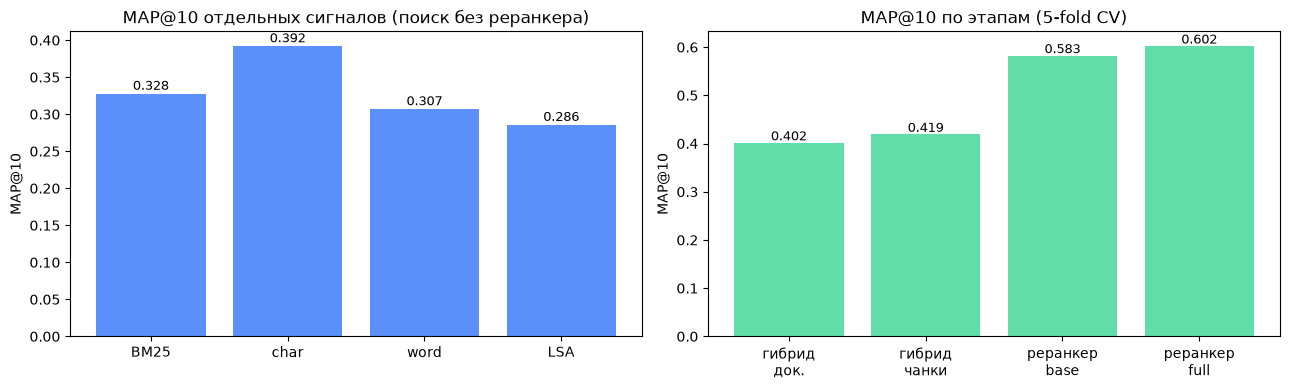

In [20]:
if HAS_PLT:
    fig, ax = plt.subplots(1, 2, figsize=(13, 4))

    ax[0].bar(list(signal_maps.keys()), list(signal_maps.values()), color="#5B8FF9")
    ax[0].set_title("MAP@10 отдельных сигналов (поиск без реранкера)")
    ax[0].set_ylabel("MAP@10")
    for i, v in enumerate(signal_maps.values()):
        ax[0].text(i, v + 0.005, f"{v:.3f}", ha="center", fontsize=9)

    stages = ["гибрид\nдок.", "гибрид\nчанки", "реранкер\nbase", "реранкер\nfull"]
    vals = [map_hyb_doc, map_hyb_chunk, map_rerank_base, map_rerank_full]
    ax[1].bar(stages, vals, color="#61DDAA")
    ax[1].set_title("MAP@10 по этапам (5-fold CV)")
    ax[1].set_ylabel("MAP@10")
    for i, v in enumerate(vals):
        ax[1].text(i, v + 0.005, f"{v:.3f}", ha="center", fontsize=9)
    plt.tight_layout()
    plt.show()

else:
    print("matplotlib не установлен - графики пропущены (pip install matplotlib)")

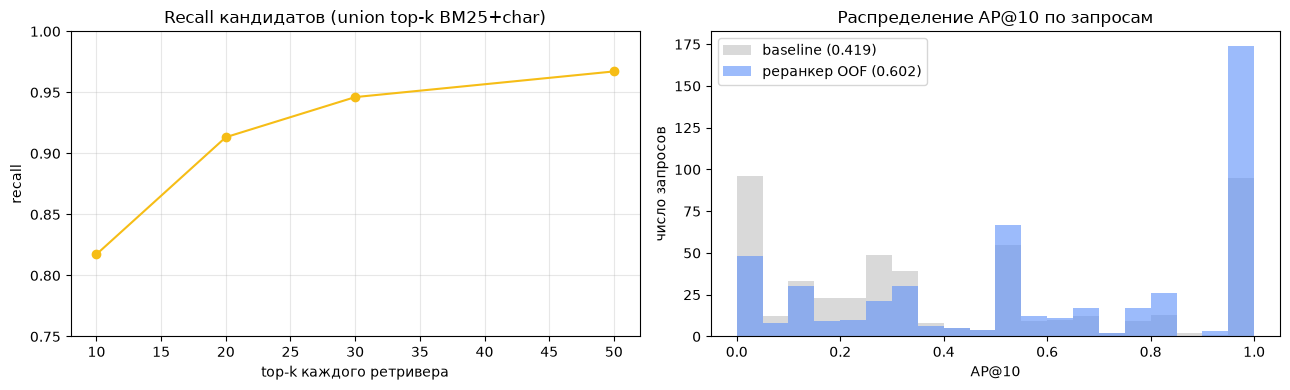

In [21]:
if HAS_PLT:
    fig, ax = plt.subplots(1, 2, figsize=(13, 4))

    ns = list(recall_curve.keys())
    ax[0].plot(ns, [recall_curve[n] for n in ns], marker="o", color="#F6BD16")
    ax[0].set_title("Recall кандидатов (union top-k BM25+char)")
    ax[0].set_xlabel("top-k каждого ретривера")
    ax[0].set_ylabel("recall")
    ax[0].set_ylim(0.75, 1.0)
    ax[0].grid(alpha=0.3)

    ax[1].hist(aps_baseline, bins=20, alpha=0.6, label=f"baseline ({aps_baseline.mean():.3f})", color="#C0C0C0")
    ax[1].hist(oof_full_ap, bins=20, alpha=0.6, label=f"реранкер OOF ({oof_full_ap.mean():.3f})", color="#5B8FF9")
    ax[1].set_title("Распределение AP@10 по запросам")
    ax[1].set_xlabel("AP@10")
    ax[1].set_ylabel("число запросов")
    ax[1].legend()
    plt.tight_layout()
    plt.show()

else:
    print("matplotlib не установлен - графики пропущены (pip install matplotlib)")

## Итоги

| Вариант | MAP@10 (5-fold CV) |
|-|-|
| гибрид по документам | 0.402 |
| гибрид по чанкам (baseline) | 0.419 |
| + реранкер (BM25+char) | 0.591 |
| + word/LSA/эмбеддинги | **0.596** |

Прирост дали: разбиение статей на пассажи, переранжирование кандидатов бустингом и добавление словесных, латентно-семантических (LSA) и нейросетевых сигналов к чисто лексическим.

Что осталось: обучаемый ранжирующий лосс (LambdaMART/LGBMRanker вместо pointwise-классификации), словарь синонимов предметной области, нарезка по границам HTML-блоков вместо равномерных окон.

Числа выше - 5-fold CV на calibration для лексической конфигурации (в этом прогоне эмбеддинги не устанавливались). С локальными эмбеддингами full-строка выше - точное значение печатается ячейкой ablation при прогоне. На публичном тесте оценка обычно на ~0.03-0.04 ниже CV.
